# Tests — parameter estimation (LMC model)

Validation of the **direct LMC** spatial model (the `\new{}` model in [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex)): three latent fields $W^c, W^{(0)}, W^{(1)}$, mixing weight $\lambda$, parameter $\theta=(\lambda,\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$ — and of its **state-dependent-$\lambda^{(r)}$ variant** (the blue "alternative suggestion" in main.tex, $\theta=(\lambda^{(0)},\lambda^{(1)},\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$, section 1.b below). The single-latent-field model and its tests are archived under [archive_old_single_latent_field/](archive_old_single_latent_field/).

We check that the **vectorized `approx_cdf` pairwise MLE** recovers a known $\theta$:

1. $\theta$ recovery on simulated data via `run_simulation_mle_experiment` / `mle_theta_pairwise` — for both the shared-$\lambda$ model (1.) and the state-dependent-$\lambda^{(r)}$ variant (1.b),
2. reduction to the old single-field model at $\lambda=1$,
3. classic `scipy.phi2` vs vectorized `approx_cdf` — same $\hat\theta$, large speed-up,
4. robustness to missing data.

Histories are drawn with the Cholesky simulator `simulate_cholesky` (three latent factors, with burn-in). The `approx_cdf` kernel itself is derived in [approx_cdf_adaptation/approx_cdf_explained.ipynb](approx_cdf_adaptation/approx_cdf_explained.ipynb).

## Setup

Build `dict_model_params` exactly as in the pipeline notebook (imports, single-site fit outputs, station subset, exit-probability closures). These helpers are model-agnostic and shared with the old model.

In [1]:
import sys, pathlib
_HERE = pathlib.Path.cwd().resolve()
_REPO_ROOT = next(
    (p for p in (_HERE, *_HERE.parents) if (p / "article_code").is_dir()),
    None,
)
if _REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root containing 'article_code/' from {_HERE}")
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from article_code.util_files import config
from spatial_bmcd.spatial_model import (
    prepare_station_fit_table,
    build_dict_model_params,
    run_simulation_mle_experiment,
    simulate_cholesky,
    mle_theta_pairwise,
    pairwise_loglik_given_theta,
    build_lmc_blocks,
    build_C_from_sigma,
    normalize_theta,
    THETA_BOUNDS_STATE_DEP,
    THETA_X0_STATE_DEP,
)
from spatial_bmcd.spatial_plotting import plot_stations_geomap

In [2]:
# Load single-site outputs produced by notebook 01.
base_filename = (
    f"ecad_data_south_europe_filtered_after_{config.START_YEAR}"
    f"_wet_day_thresh_{config.WET_DAY_THRESHOLD}.json"
)
with open(config.EXPORTS_JSON_DIR / base_filename) as fh:
    spells = json.load(fh)

stations_metadata = pd.read_csv(config.STATION_METADATA_CSV)
stations_used = stations_metadata[stations_metadata["city"].isin(spells.keys())]

fit_folder = (
    config.RESULTS_FIT_DIR
    / f"fit_south_europe_subset_excess_over_{config.WET_DAY_THRESHOLD}"
)
df_fit_dry = pd.read_csv(fit_folder / "dry_spell_fit_egpd1_excess_over_1result_fit_parameters.csv")
df_fit_wet = pd.read_csv(fit_folder / "wet_spell_fit_mixt_geomresult_fit_parameters.csv")
df_fit_dry["city"] = df_fit_dry["data_source"].map(lambda s: s.split()[0])
df_fit_dry["season"] = df_fit_dry["data_source"].map(lambda s: s.split()[-1])

print(f"{len(spells)} stations in spells JSON; {len(stations_used)} in metadata")

209 stations in spells JSON; 209 in metadata


In [3]:
COUNTRIES = ["PT", "ES"]
SEASON = "spring"

df_fit_dry_sub, df_fit_wet_sub = prepare_station_fit_table(
    df_fit_dry, df_fit_wet, stations_used,
    countries=COUNTRIES, season=SEASON,
)
print(f"{len(df_fit_dry_sub)} stations kept for season={SEASON}, countries={COUNTRIES}")

dict_model_params = build_dict_model_params(
    df_fit_dry_sub, df_fit_wet_sub, spells, season=SEASON,
)
print(f"Built model parameters for {len(dict_model_params)} stations")

35 stations kept for season=spring, countries=['PT', 'ES']


100%|██████████| 35/35 [00:00<00:00, 224.36it/s]

Built model parameters for 35 stations


## 1. Maximum-likelihood estimation of $\theta$ on simulated data

**Model fitted here: the original shared-$\lambda$ LMC** of [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex) — a single mixing weight $\lambda$ common to the dry and wet fields, Eq. (4) (`lmc_fields_direct`):

$$
Z^{(r)}_n(\mathbf{s})=(-1)^{r}\sqrt{\lambda}\,W^{(c)}_n(\mathbf{s})+\sqrt{1-\lambda}\,W^{(r)}_n(\mathbf{s}),
\qquad r\in\{0,1\},\quad \lambda\in[0,1].
\tag{4}
$$

Simulate spatial histories with a known $\theta=(\lambda,\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$ and recover it via `run_simulation_mle_experiment` (which calls `mle_theta_pairwise`). Each row of the returned DataFrame is one independent simulation; `simulator="cholesky"` (default) factors the three latent covariances once.

In [4]:
THETA_TRUE = (0.6, 0.30, 0.15, 0.45)   # (lambda, sigma_wc, sigma_w0, sigma_w1)

# Histories kept short so the 4-D MLE stays quick here; recovery is correspondingly
# noisier than a long real-data fit but still centred on theta_true.
df = run_simulation_mle_experiment(
    dict_model_params, theta_true=THETA_TRUE,
    nb_stations=20, nb_steps=5000, nb_estimations=1,
    vectorized=True, simulator="cholesky",
)
print(f"theta_true = (lam, s_wc, s_w0, s_w1) = {THETA_TRUE}")
print(df[["i", "lam_hat", "sigma_wc_hat", "sigma_w0_hat", "sigma_w1_hat", "ll_hat"]].round(3).to_string(index=False))

theta_true = (lam, s_wc, s_w0, s_w1) = (0.6, 0.3, 0.15, 0.45)
 i  lam_hat  sigma_wc_hat  sigma_w0_hat  sigma_w1_hat      ll_hat
 0    0.546         0.347         0.153         0.368 -860196.567


### 1.b Alternative model: state-dependent mixing weights $\lambda^{(r)}$

**Model fitted here: the alternative suggestion of [main.tex](Spatialisation-Rain-Occurrence-Generator-article/main.tex) (blue)** — the weight $\lambda$ becomes $\lambda^{(r)}$: one parameter $\lambda^{(0)}$ for the dry Gaussian field and one parameter $\lambda^{(1)}$ for the wet Gaussian field, so $\theta=(\lambda^{(0)},\lambda^{(1)},\sigma_{w^c},\sigma_{w^{(0)}},\sigma_{w^{(1)}})$. The covariance blocks of Eq. (5) (`lmc_blocks_inline`) become:

$$
C^{(r,r')}_n(\mathbf{s},\mathbf{s}')=
\begin{cases}
\lambda^{(r)}\,\rho_{w^{(c)}}(\mathbf{s},\mathbf{s}')+(1-\lambda^{(r)})\,\rho_{w^{(r)}}(\mathbf{s},\mathbf{s}'), & r=r'\ \text{(dry-dry or wet-wet)},\\[4pt]
-\,\sqrt{\lambda^{(0)}\lambda^{(1)}}\,\rho_{w^{(c)}}(\mathbf{s},\mathbf{s}'), & r\neq r'\ \text{(dry-wet)}.
\end{cases}
\tag{5'}
$$

The shared-$\lambda$ model of section 1. is the special case $\lambda^{(0)}=\lambda^{(1)}=\lambda$. Same experiment as above: a 5-component `theta_true` selects this variant everywhere in [spatial_model.py](spatial_model.py) (`normalize_theta` dispatches on the length), and `run_simulation_mle_experiment` then automatically fits the 5-D pairwise MLE (`THETA_BOUNDS_STATE_DEP` / `THETA_X0_STATE_DEP`).

In [4]:
THETA_TRUE_STATE_DEP = (0.35, 0.75, 0.30, 0.15, 0.45)   # (lam0, lam1, sigma_wc, sigma_w0, sigma_w1)

# Distinct lam0 != lam1 so the state-dependent weights are actually exercised.
# Same sizes as the shared-lambda experiment above; the 5-D MLE is somewhat
# noisier (one extra parameter, cross-block only identifies sqrt(lam0*lam1)).
df_sd = run_simulation_mle_experiment(
    dict_model_params, theta_true=THETA_TRUE_STATE_DEP,
    nb_stations=50, nb_steps=1000, nb_estimations=1,
    vectorized=True, simulator="cholesky",
)
print(f"theta_true = (lam0, lam1, s_wc, s_w0, s_w1) = {THETA_TRUE_STATE_DEP}")
print(df_sd[["i", "lam0_hat", "lam1_hat", "sigma_wc_hat", "sigma_w0_hat", "sigma_w1_hat", "ll_hat"]].round(3).to_string(index=False))

KeyboardInterrupt: 

### Consistency in `nb_steps`

The pairwise composite MLE is consistent, so $\hat\theta$ should concentrate around $\theta_{\text{true}}$ as the history grows. For every history length $T$ we run **5 independent estimations** (seeds $0\ldots4$): each seed simulates one long history and is re-fitted on nested prefixes (first $T$ steps), so the error decay is visible at fixed randomness.

The experiment is split into two cells so the (slow) MLEs run once and the plot can be re-drawn freely:

- **Run + save** — computes `err_stack[s, t, k] = |\hat\theta_k - \theta_{\text{true},k}|` for each seed $s$, history length $T$, component $k$, and saves it (with metadata) to `experiment_outputs/theta_consistency.npz`. This is the expensive cell (5 seeds $\times$ 5 lengths $=25$ vectorized 4-D MLEs, several minutes).
- **Plot** — reloads the `.npz` and draws the figure. Re-run it alone to try other plots without redoing any MLE.

**Error metric.** Everything is reported as a **mean percentage error (MPE)** so the four components are on the same dimensionless scale and directly comparable. For a single fit the per-component percentage error is $100\,|\hat\theta_k-\theta_{\text{true},k}|/\theta_{\text{true},k}$; averaging over the 5 replicates gives the MPE plotted for each component, with error bars at $\pm1$ standard deviation across the replicates. The programmatic check at the end averages the four per-component percentage errors and requires that aggregate to decrease from the shortest to the longest history.

In [4]:
THETA_TRUE = (0.6, 0.30, 0.15, 0.45)   # (lambda, sigma_wc, sigma_w0, sigma_w1)
NB_STEPS_GRID = [500, 2000, 4000, 10000]
SEEDS = [0, 1, 2, 3, 4, 5,6,7,8,9]                 # 10 estimations per history length
KEYS = ["lam", "sigma_wc", "sigma_w0", "sigma_w1"]
th_true = normalize_theta(THETA_TRUE)

names8 = sorted(dict_model_params)[:8]
params8 = {c: dict_model_params[c] for c in names8}

def _prefix(h, T):
    """Restrict a simulated history to its first T steps (R/D have T+1 rows, S has T)."""
    return {**h, "R": h["R"][:T + 1], "D": h["D"][:T + 1], "S": h["S"][:T]}

# For each seed simulate one long history and re-fit on nested prefixes.
# err_stack[s, t, k] = |theta_hat - theta_true| for seed s, length NB_STEPS_GRID[t], component KEYS[k].
err_stack = np.empty((len(SEEDS), len(NB_STEPS_GRID), len(KEYS)))
for s, seed in enumerate(tqdm(SEEDS)):
    hist = simulate_cholesky(THETA_TRUE, params8, n_steps=max(NB_STEPS_GRID), n_burn=200, seed=seed)
    for t, T in enumerate(NB_STEPS_GRID):
        th = mle_theta_pairwise(_prefix(hist, T), params8, vectorized=True)["theta_hat"]
        err_stack[s, t, :] = [abs(th[k] - th_true[k]) for k in KEYS]

# Persist the raw errors + metadata so the plotting cell below can be re-run (and other
# plots tried) without redoing the 25 vectorized 4-D MLEs above.
RESULTS_PATH = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs" / "theta_consistency.npz"
RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
np.savez(
    RESULTS_PATH,
    err_stack=err_stack,
    nb_steps_grid=np.array(NB_STEPS_GRID),
    seeds=np.array(SEEDS),
    keys=np.array(KEYS),
    theta_true=np.array([th_true[k] for k in KEYS]),
)
print(f"saved raw errors to {RESULTS_PATH}")
print(f"  err_stack shape {err_stack.shape} = [seeds={len(SEEDS)}, lengths={len(NB_STEPS_GRID)}, components={len(KEYS)}]")

 30%|███       | 3/10 [3:47:50<8:51:36, 4556.69s/it]


KeyboardInterrupt: 

theta_true = (np.float64(0.6), np.float64(0.3), np.float64(0.15), np.float64(0.45)) -- J=8, seeds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)], nested prefixes
error = mean percentage error (%) over replicates; error bars = +/-1 std of 100*|theta_hat-theta_true|/theta_true
       MPE%_lam  MPE%_sigma_wc  MPE%_sigma_w0  MPE%_sigma_w1
500        8.96          25.28          72.01         155.68
2000      10.18          18.07          19.17          72.13
4000       8.02           6.40           6.24          28.15
10000      6.84           5.80           9.70          30.48


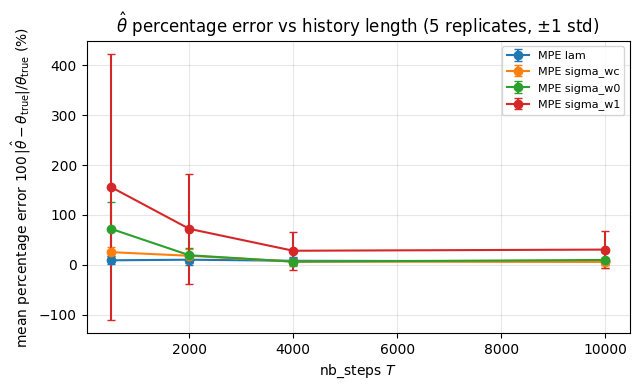

OK: mean percentage error decreases (65.5% at T=500 -> 13.2% at T=10000)


In [11]:
# --- Plot only (re-runnable without the experiment above): loads the saved .npz. ---
RESULTS_PATH = _REPO_ROOT / "spatial_bmcd" / "experiment_outputs" / "theta_consistency.npz"
data = np.load(RESULTS_PATH, allow_pickle=True)
err_stack     = data["err_stack"]
NB_STEPS_GRID = list(data["nb_steps_grid"])
SEEDS         = list(data["seeds"])
KEYS          = [str(k) for k in data["keys"]]
theta_true    = data["theta_true"]

# Percentage error puts every component on the same dimensionless scale, so the four
# curves are directly comparable: pct[s, t, k] = 100 * |theta_hat - theta_true| / theta_true.
pct_stack = 100.0 * err_stack / theta_true                # broadcast over component axis
mpe     = pd.DataFrame(pct_stack.mean(axis=0),        index=NB_STEPS_GRID, columns=KEYS)
mpe_std = pd.DataFrame(pct_stack.std(axis=0, ddof=1), index=NB_STEPS_GRID, columns=KEYS)

# Aggregate mean percentage error (programmatic check only, not plotted or tabulated):
# average the per-component percentage error per replicate, then mean over the replicates.
agg = pct_stack.mean(axis=2).mean(axis=0)                 # (n_T,)

summary = mpe.copy()
summary.columns = [f"MPE%_{k}" for k in KEYS]
print(f"theta_true = {tuple(np.round(theta_true, 4))} -- J=8, seeds={SEEDS}, nested prefixes")
print("error = mean percentage error (%) over replicates; error bars = +/-1 std of 100*|theta_hat-theta_true|/theta_true")
print(summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4))
for k in KEYS:
    ax.errorbar(NB_STEPS_GRID, mpe[k], yerr=mpe_std[k], fmt="o-", capsize=3, label=f"MPE {k}")
ax.set_xlabel("nb_steps $T$")
ax.set_ylabel(r"mean percentage error $100\,|\hat\theta-\theta_{\mathrm{true}}|/\theta_{\mathrm{true}}$ (%)")
ax.set_title(r"$\hat\theta$ percentage error vs history length (5 replicates, $\pm1$ std)")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

assert agg[-1] < agg[0], \
    "estimation error should decrease from the shortest to the longest history"
print("OK: mean percentage error decreases "
      f"({agg[0]:.1f}% at T={NB_STEPS_GRID[0]} -> {agg[-1]:.1f}% at T={NB_STEPS_GRID[-1]})")

## 2. Speed-up of the fast likelihood approximation `approx_cdf`

The bottleneck is the bivariate-normal CDF $\Phi_2$. The scalar baseline rebuilds a `scipy.stats.multivariate_normal` per station pair; `vectorized=True` switches to `phi2_vec`, the closed-form Tsay & Ke (2021) port that vectorizes over all pairs of a step. Because the two kernels return the **same** likelihood (to ~$10^{-3}$ per pair), they share the same argmax $\hat\theta$ — we show this on a single likelihood evaluation at `THETA_TRUE`, then run the full 4-D MLE with the fast kernel only (the scalar 4-D L-BFGS-B is impractically slow).

In [6]:
import time

names8 = sorted(dict_model_params)[:8]
params8 = {c: dict_model_params[c] for c in names8}
sim_hist = simulate_cholesky(THETA_TRUE, params8, n_steps=1000, n_burn=300, seed=1)

# Same likelihood, two kernels: one evaluation at theta_true (fast).
t0 = time.perf_counter(); ll_slow = pairwise_loglik_given_theta(sim_hist, params8, THETA_TRUE, vectorized=False); t_slow = time.perf_counter() - t0
t0 = time.perf_counter(); ll_fast = pairwise_loglik_given_theta(sim_hist, params8, THETA_TRUE, vectorized=True); t_fast = time.perf_counter() - t0
print(f"J={len(params8)}, T={sim_hist['S'].shape[0]}  -- pairwise log-likelihood at theta_true")
print(f"  scipy phi2 (scalar) : ll={ll_slow:.3f}  ({t_slow:.3f}s)")
print(f"  approx_cdf (vector) : ll={ll_fast:.3f}  ({t_fast:.3f}s)")
print(f"  rel |d ll| = {abs(ll_slow - ll_fast) / abs(ll_slow):.2e}   per-eval speedup = {t_slow / t_fast:.0f}x")

# Full 4-D MLE with the vectorized kernel only.
t0 = time.perf_counter(); r = mle_theta_pairwise(sim_hist, params8, vectorized=True); t = time.perf_counter() - t0
th = r["theta_hat"]
print(f"  vectorized MLE theta_hat = ({th['lam']:.3f}, {th['sigma_wc']:.3f}, {th['sigma_w0']:.3f}, {th['sigma_w1']:.3f})  ({t:.1f}s)")

J=8, T=1000  -- pairwise log-likelihood at theta_true
  scipy phi2 (scalar) : ll=-25231.055  (13.680s)
  approx_cdf (vector) : ll=-25231.171  (0.750s)
  rel |d ll| = 4.57e-06   per-eval speedup = 18x
  vectorized MLE theta_hat = (0.555, 0.326, 0.110, 0.623)  (101.9s)


## 3. Robustness to missing data

Same experiment, but with 10% of stations randomly masked at every time step. The pairwise likelihood is NaN-aware, so the estimator should still recover $\theta$.

In [7]:
df_nan = run_simulation_mle_experiment(
    dict_model_params, theta_true=THETA_TRUE,
    nb_stations=8, nb_steps=5000, nb_estimations=2,
    inject_nan_frac=0.10, vectorized=True,
)
print(f"theta_true={THETA_TRUE}, frac_nan=0.10")
print(df_nan[["i", "lam_hat", "sigma_wc_hat", "sigma_w0_hat", "sigma_w1_hat", "mean_nb_obs_stations"]].round(3).to_string(index=False))

KeyboardInterrupt: 